In [3]:
!pip install alerce
!pip install opencv-python
!pip install scikeras
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.8.0
!pip install astroquery
!export PATH="$HOME/.local/bin:$PATH"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 144.0 MB/s eta 0:00:0000:0100:01
Defaulting to user installation because normal site-packages is not writeable
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.

In [1]:
from alerce.core import Alerce

alerce = Alerce()
objects = alerce.query_objects(oid=oids, format="pandas")

In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns
from scikeras.wrappers import KerasClassifier
from alerce.core import Alerce
import warnings
import os

2026-03-24 11:53:35.080146: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 11:53:39.951773: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 11:53:55.274805: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
all_curves = []
all_oids = []
N_POINTS = 200
csv_dir = "PHYS324/csv_files"
"""
normal_objects = alerce.query_objects(
            survey="ztf", 
            format='pandas', 
            classifier_name='LC Classifier',
            class_name='SNII',
            page_size=50
)
normal_oids = normal_objects['oid'].tolist()

for oid in normal_oids:
    df = alerce.query_detections(oid, format="pandas")"""

for fname in os.listdir(csv_dir):
    oid = fname.replace(".csv", "")
    df = pd.read_csv(os.path.join(csv_dir, fname))
    g = df[df['fid'] == 1]
    r = df[df['fid'] == 2]
    if len(r) < 3 or len(g) < 3 or len(r) > 250 or len(g) > 250:
            continue
    color_offset = g['magpsf'].median() - r['magpsf'].median()  # to project r onto j
    mag = r['magpsf'].values + color_offset
    mag_norm = (mag - mag.min()) / (mag.max() - mag.min())
    indices = np.round(np.linspace(0, len(mag_norm) - 1, N_POINTS)).astype(int)
    mag_resampled = mag_norm[indices]
    if np.any(np.isnan(mag_resampled)):
            continue
    all_curves.append(mag_resampled)
    all_oids.append(oid)
curves = np.array(all_curves)
print(f"Collected {len(curves)} curves")

Collected 5324 curves


In [ ]:
mean_dist = np.mean(np.abs(curves[:, None, :] - curves[None, :, :]), axis=(0, 1))  # (200,)
deriv = np.diff(curves, axis=1)  # (n, 199)
mean_dist_deriv = np.mean(np.abs(deriv[:, None, :] - deriv[None, :, :]), axis=(0, 1))
peaks_curve, _ = find_peaks(mean_dist)
peaks_deriv, _ = find_peaks(mean_dist_deriv, width=10)
def get_segments(peaks, total_len, half_window):
    segments = []
    for p in peaks:
        lo = max(0, p - half_window)
        hi = min(total_len, p + half_window)
        segments.append((lo, hi))
    return segments
curve_segs = get_segments(peaks_curve, N_POINTS, 20)
deriv_segs = get_segments(peaks_deriv, N_POINTS - 1, 10)

print(f"Curve segments: {len(curve_segs)}, Derivative segments: {len(deriv_segs)}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mean_dist)
plt.plot(peaks_curve, mean_dist[peaks_curve], 'rx')
plt.title('Mean distance for curve')
plt.subplot(1, 2, 2)
plt.plot(mean_dist_deriv)
plt.plot(peaks_deriv, mean_dist_deriv[peaks_deriv], 'rx')
plt.title('Mean distance for derivative')
plt.tight_layout()
plt.show()

In [ ]:
def cluster_segment(data, eps_percentile=10, min_samples=3):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    from sklearn.metrics import pairwise_distances
    dists = pairwise_distances(data_scaled).flatten()
    eps = np.percentile(dists[dists > 0], eps_percentile)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    return db.fit_predict(data_scaled)

label_matrix = [] 

for lo, hi in curve_segs:
    seg_data = curves[:, lo:hi]
    labels = cluster_segment(seg_data, 2, 10)
    label_matrix.append(labels)

for lo, hi in deriv_segs:
    seg_data = deriv[:, lo:hi]
    labels = cluster_segment(seg_data, 2, 10)
    label_matrix.append(labels)

label_matrix = np.array(label_matrix).T  # (n_curves, n_segments)
print("Label matrix shape:", label_matrix.shape) 

In [ ]:
from collections import Counter

label_tuples = [tuple(row) for row in label_matrix]
label_counts = Counter(label_tuples)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (label_vec, count) in zip(axes, label_counts.most_common(8)):
    idxs = [i for i, t in enumerate(label_tuples) if t == label_vec]
    for i in idxs:
        ax.plot(curves[i], alpha=0.4, linewidth=0.8)
    has_anomaly = any(v < 0 for v in label_vec)
    ax.invert_yaxis()
    ax.set_xlabel('Channel')
    ax.set_ylabel('Norm. mag')

plt.tight_layout()
plt.show()

In [ ]:
normal_idxs = [i for i, t in enumerate(label_tuples) if all(v >= 0 for v in t)]
anomaly_idxs = [i for i, t in enumerate(label_tuples) if any(v < 0 for v in t)]

good_oids = [all_oids[idx] for idx in normal_idxs]

print(good_oids)

print(f"\nNormal curves: {len(normal_idxs)}")
print(f"Anomalous curves: {len(anomaly_idxs)}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in normal_idxs:
    plt.plot(curves[i], alpha=0.3, color='steelblue', linewidth=0.8)
plt.title(f'Normal ({len(normal_idxs)} curves)')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
for i in anomaly_idxs:
    plt.plot(curves[i], alpha=0.3, color='tomato', linewidth=0.8)
plt.title(f'Anomalous ({len(anomaly_idxs)} curves)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
def classify_new_curve(new_mag, clusters_data, label_matrix, curve_segs, deriv_segs, curves, eps_threshold=0.5):
    mag_norm = (new_mag - new_mag.min()) / (new_mag.max() - new_mag.min())
    indices = np.round(np.linspace(0, len(mag_norm) - 1, N_POINTS)).astype(int)
    new_curve = mag_norm[indices]
    new_deriv = np.diff(new_curve)

    label_tuples = [tuple(row) for row in label_matrix]
    unique_labels = [lt for lt in set(label_tuples) if all(v >= 0 for v in lt)]

    best_label = None
    best_eps_change = np.inf

    for label_vec in unique_labels:
        cluster_idxs = [i for i, t in enumerate(label_tuples) if t == label_vec]
        cluster_curves = curves[cluster_idxs]  # (n_in_cluster, N_POINTS)

        total_eps_change = 0

        for seg_idx, (lo, hi) in enumerate(curve_segs):
            cluster_seg = cluster_curves[:, lo:hi]
            new_seg = new_curve[lo:hi].reshape(1, -1)

            dists = pairwise_distances(
                np.vstack([cluster_seg, new_seg])
            )
            new_dists = dists[-1, :-1]  
            min_eps_needed = new_dists.min()

            cluster_dists = pairwise_distances(cluster_seg).flatten()
            current_eps = np.percentile(cluster_dists[cluster_dists > 0], 10)

            total_eps_change += abs(min_eps_needed - current_eps)

        for lo, hi in deriv_segs:
            cluster_seg = np.diff(cluster_curves, axis=1)[:, lo:hi]
            new_seg = new_deriv[lo:hi].reshape(1, -1)

            dists = pairwise_distances(np.vstack([cluster_seg, new_seg]))
            new_dists = dists[-1, :-1]
            min_eps_needed = new_dists.min()

            cluster_dists = pairwise_distances(cluster_seg).flatten()
            current_eps = np.percentile(cluster_dists[cluster_dists > 0], 10)

            total_eps_change += abs(min_eps_needed - current_eps)

        if total_eps_change < best_eps_change:
            best_eps_change = total_eps_change
            best_label = label_vec

    if best_eps_change > eps_threshold:
        return None, best_eps_change  # unclassifiable

    return best_label, best_eps_change

def predict(oid, threshold):
    new_df = alerce.query_detections(oid, format="pandas")
    new_r = new_df[new_df['fid'] == 2].copy()
    new_g = new_df[new_df['fid'] == 1].copy()
    
    new_r = new_r.sort_values('sigmapsf').drop_duplicates(subset='mjd', keep='first').sort_values('mjd')
    color_offset = new_g['magpsf'].median() - new_r['magpsf'].median()
    new_mag = new_r['magpsf'].values + color_offset
    
    predicted_label, eps_change = classify_new_curve(
        new_mag, None, label_matrix, curve_segs, deriv_segs, curves, threshold
    )

    mag_norm = (new_mag - new_mag.min()) / (new_mag.max() - new_mag.min())
    indices = np.round(np.linspace(0, len(mag_norm) - 1, N_POINTS)).astype(int)
    new_curve = mag_norm[indices]
    
    label_tuples = [tuple(row) for row in label_matrix]
    cluster_idxs = [i for i, t in enumerate(label_tuples) if t == predicted_label]
    
    if predicted_label is None:
        print(f"Curve is noise / unclassifiable (eps_change={eps_change:.3f})")
    else:
        has_anomaly = any(v < 0 for v in predicted_label)
        print(f"Predicted cluster: {list(predicted_label)}")
        print(f"Anomalous: {has_anomaly}")
        print(f"EPS change: {eps_change:.3f}")
    plt.figure(figsize=(8, 4))
    for i in cluster_idxs:
        plt.plot(curves[i], alpha=0.3, color='steelblue', linewidth=0.8)
    plt.plot(new_curve, color='red', linewidth=2, label='New curve')
    plt.gca().invert_yaxis()
    plt.legend()
    plt.show()

Predicted cluster: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Anomalous: False
EPS change: 10.415


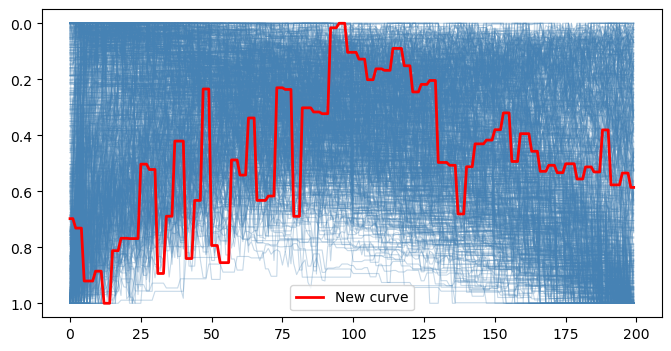

In [32]:
# threshold is how much eps_change for classification
predict("ZTF19aaskmyg", 15)